In [1]:
''' Recurrent neural network (RNN) Use the Google stock prices dataset and design a time series
analysis and prediction system using RNN.
'''

' Recurrent neural network (RNN) Use the Google stock prices dataset and design a time series\nanalysis and prediction system using RNN.\n'

In [1]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,SimpleRNN

In [2]:
dataset_train = pd.read_csv("Google_Stock_Price_Train.csv")

training_set = dataset_train.iloc[:, 1:2].values

In [3]:
sc = MinMaxScaler(feature_range=(0,1))

training_set_scaled = sc.fit_transform(training_set)

In [4]:
X_train = []
y_train = []

for i in range(60, 1258):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [5]:
print(X_train.shape)

(1198, 60)


In [6]:
X_train = np.reshape(X_train,
                     (X_train.shape[0],
                      X_train.shape[1],
                      1))

In [7]:
model = Sequential()

In [8]:
model.add(SimpleRNN(units=50,
                    return_sequences=True,
                    input_shape=(X_train.shape[1],1)))

model.add(Dropout(0.2))

C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.add(SimpleRNN(units=50,
                    return_sequences=True))

model.add(Dropout(0.2))

In [10]:
model.add(SimpleRNN(units=50,
                    return_sequences=True))

model.add(Dropout(0.2))

In [11]:
model.add(SimpleRNN(units=50))

model.add(Dropout(0.2))

In [12]:
model.add(Dense(units=1))

In [13]:
model.compile(optimizer='adam',
              loss='mean_squared_error')

In [14]:
model.fit(X_train,
          y_train,
          epochs=100,
          batch_size=32)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - loss: 0.3678
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.2114 
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.1671 
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.1240
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0990 
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0874 
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0709 
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0566 
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0517 
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0454 
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0326 
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0318 
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0309 
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0244 
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 7

In [16]:
dataset_test = pd.read_csv("Google_Stock_Price_Test.csv")

real_stock_price = dataset_test.iloc[:,1:2].values

In [17]:
dataset_total = pd.concat((dataset_train['Open'],
                           dataset_test['Open']),
                           axis=0)

In [18]:
inputs = dataset_total[len(dataset_total) -
                       len(dataset_test) - 60:].values

inputs = inputs.reshape(-1,1)

inputs = sc.transform(inputs)

In [19]:
X_test = []

for i in range(60, 80):
    X_test.append(inputs[i-60:i,0])

X_test = np.array(X_test)

X_test = np.reshape(X_test,
                    (X_test.shape[0],
                     X_test.shape[1],
                     1))

In [20]:
predicted_stock_price = model.predict(X_test)

predicted_stock_price = sc.inverse_transform(
                        predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


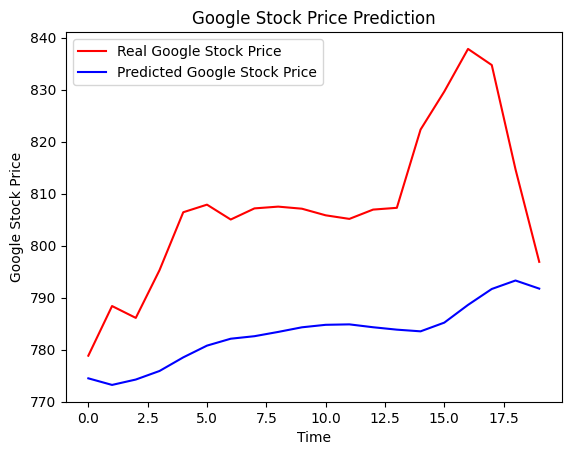

In [21]:
plt.plot(real_stock_price,
         color='red',
         label='Real Google Stock Price')

plt.plot(predicted_stock_price,
         color='blue',
         label='Predicted Google Stock Price')

plt.title('Google Stock Price Prediction')

plt.xlabel('Time')

plt.ylabel('Google Stock Price')

plt.legend()

plt.show()